In [1]:
import os
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix
from sklearn.datasets import fetch_20newsgroups
import pickle
from datasets import load_dataset


C:\Users\fidel\miniconda3\envs\ML-XAI\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
data = fetch_20newsgroups(subset='test',remove=('headers', 'footers', 'quotes'))
df_test = pd.DataFrame({
    'text': data.data,
    'target': data.target,
    'target_name': [data.target_names[i] for i in data.target]
})

X = df_test['text']
y = df_test['target']


In [2]:
ag_data = load_dataset("ag_news")

X_test = ag_data['test']["text"]
y_test = ag_data['test']['label']


In [3]:
pipeline_dir = '../02_Pipeline/saved_pipelines_AGnews'

test_results = []

for filename in os.listdir(pipeline_dir):
    if filename.endswith('.pkl'):
        path = os.path.join(pipeline_dir, filename)
        vectorizer_name, model_name = filename.replace('.pkl', '').split('_', 1)
        try:
            with open(path, 'rb') as f:
                pipeline = pickle.load(f)

            y_pred = pipeline.predict(X_test)
            f1 = f1_score(y_test, y_pred, average='weighted')

            print(f"{filename} — F1: {f1:.4f}")

            test_results.append({
                'vectorizer': vectorizer_name,
                'model_name': model_name,
                'f1_score': f1
            })

        except Exception as e:
            print(f"Error loading or evaluating {filename}: {e}")
            test_results.append({
                'pipeline': filename,
                'f1_score': None,
                'error': str(e)
            })


df_test_results = pd.DataFrame(test_results)

Batches: 100%|██████████| 238/238 [00:54<00:00,  4.36it/s]


sbert_dt.pkl — F1: 0.8937


Batches: 100%|██████████| 238/238 [00:54<00:00,  4.40it/s]


sbert_mlp.pkl — F1: 0.9131


Batches: 100%|██████████| 238/238 [00:55<00:00,  4.25it/s]


sbert_svm.pkl — F1: 0.8999
tfidf_dt.pkl — F1: 0.8303
tfidf_mlp.pkl — F1: 0.9151
tfidf_svm.pkl — F1: 0.9171


In [4]:
df_test_results.head()

,vectorizer,model_name,f1_score
0,sbert,dt,0.893712
1,sbert,mlp,0.913068
2,sbert,svm,0.899850
3,tfidf,dt,0.830344
4,tfidf,mlp,0.915055


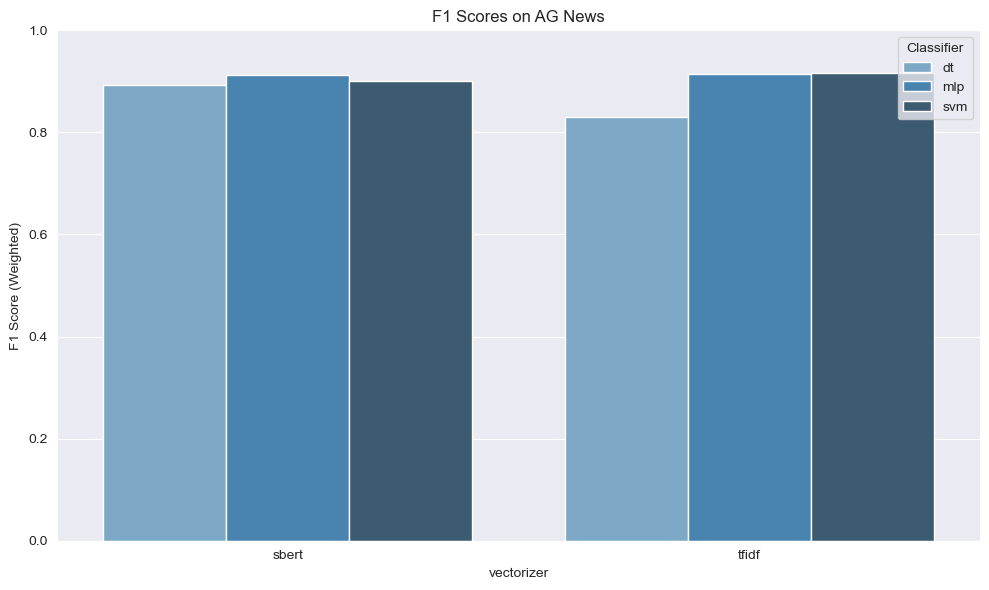

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df_test_results, x="vectorizer", y="f1_score", hue="model_name", palette="Blues_d")

plt.title("F1 Scores on AG News")
plt.ylabel("F1 Score (Weighted)")
plt.ylim(0, 1)
plt.legend(title="Classifier", loc="upper right")
plt.tight_layout()

df_test_results.to_csv("../evaluation/out/f1_scores_AGnews.csv", index=False)

plt.savefig("../evaluation/out/f1_scoresAGnews.png", dpi=300)

plt.show()


In [6]:
df_full = pd.read_csv("../evaluation/out/f1_scores_full_text.csv")
df_llm = pd.read_csv("../evaluation/out/f1_scores_llm_summary.csv")
df_sumy = pd.read_csv("../evaluation/out/f1_scores_sumy_summary.csv")

df_full["summary_type"] = "full"
df_llm["summary_type"] = "llm"
df_sumy["summary_type"] = "sumy"

df_combined = pd.concat([df_full, df_llm, df_sumy], ignore_index=True)
df_avg = df_combined.groupby(["vectorizer", "summary_type"], as_index=False)["f1_score"].mean()

# Optional: check structure
print(df_combined.head())

  vectorizer model_name  f1_score summary_type
0    doc2vec         dt  0.296758         full
1    doc2vec        mlp  0.358190         full
2    doc2vec        svm  0.318597         full
3      sbert         dt  0.609260         full
4      sbert        mlp  0.637946         full


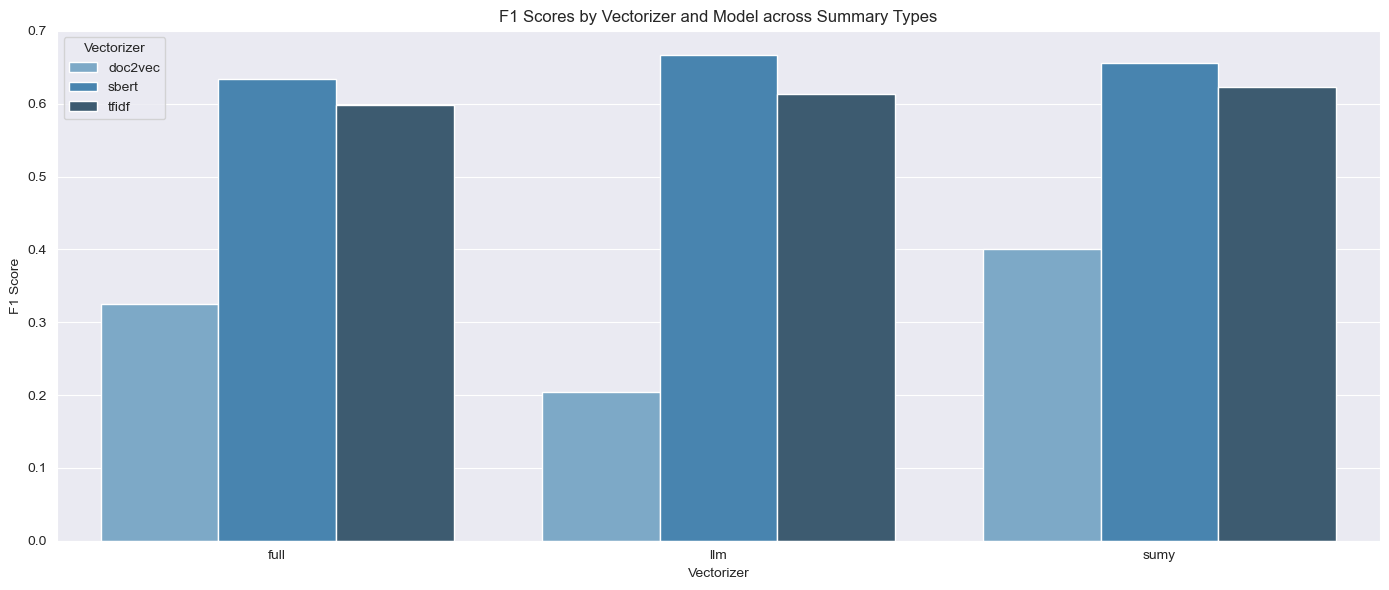

In [7]:
plt.figure(figsize=(14, 6))
sns.barplot(data=df_avg, x='summary_type', y='f1_score', hue='vectorizer', palette="Blues_d")
plt.title('F1 Scores by Vectorizer and Model across Summary Types')
plt.xlabel('Vectorizer')
plt.ylabel('F1 Score')
plt.legend(title='Vectorizer')
plt.tight_layout()
plt.show()


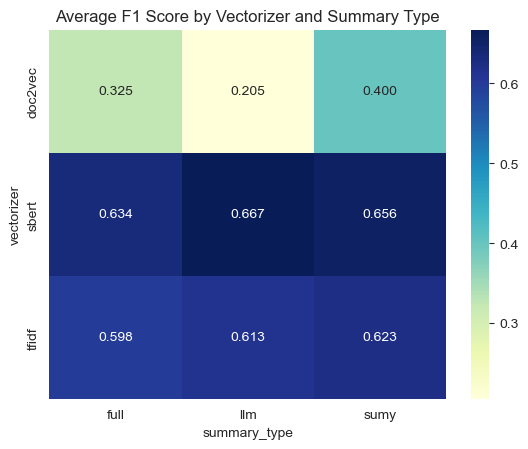

In [9]:
pivot = df_combined.groupby(['vectorizer', 'summary_type'])['f1_score'].mean().reset_index()
heatmap_data = pivot.pivot(index='vectorizer', columns='summary_type', values='f1_score')

sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", fmt=".3f")
plt.title("Average F1 Score by Vectorizer and Summary Type")

plt.savefig("../evaluation/out/summary.png", dpi=300)
plt.show()